# EE 344 — Assignment 5: Power-System Fault Classification with Deep Neural Networks

In this assignment, you will predict **power-system fault conditions** from 6 input measurements using **PyTorch**.
There are many ways to implement DNNs for prediction tasks; here you will implement and compare **three** common setups.

**Dataset**: `classData.csv`

**Inputs**: `[Ia, Ib, Ic, Va, Vb, Vc]`  
**Outputs**: 4-bit label `[G, C, B, A]`

Dataset (Kaggle): https://www.kaggle.com/datasets/esathyaprakash/electrical-fault-detection-and-classification

**Note:** Do **NOT** download the dataset from Kaggle. Use the dataset file provided on Canvas with this assignment.

Your tasks:
1. **Part 1** — Regression-style DNN to predict 4 outputs (then round to bits).
2. **Part 2** — Multi-label DNN to predict 4 bits (sigmoid / BCE-style loss).
3. **Part 3** — Multi-class DNN to predict no fault and 5 fault types (softmax / cross-entropy).
4. **Part 4** — Brief discussion: which approach is best and why.
5. **Part 5** — Open-ended: build a **binary** classifier (Fault vs No Fault) using the best approach.


## Setup
Run the next cell to import libraries and define helper functions.

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def plot_cm(cm, title, labels):
    plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=45, ha='right')
    plt.yticks(ticks, labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

def bit_reports(Y_true_bits, Y_pred_bits, split_name='Test', bit_names=('G','C','B','A')):
    """Multi-label report + per-bit 2x2 confusion matrices."""
    print(f"\n=== Bit-level Report | {split_name} ===")
    print(classification_report(Y_true_bits, Y_pred_bits, target_names=list(bit_names), digits=4))
    for j, lab in enumerate(bit_names):
        cm = confusion_matrix(Y_true_bits[:, j], Y_pred_bits[:, j], labels=[0, 1])
        print(f"\nBit {lab} | {split_name} CM (rows=true 0/1, cols=pred 0/1):\n{cm}")


Device: cpu


## Dataset

The file `classData.csv` contains a dataset for classifying fault conditions.

- **Inputs**: `[Ia, Ib, Ic, Va, Vb, Vc]`
- **Outputs**: `[G, C, B, A]`

Examples:
- `[0 0 0 0]` — No Fault
- `[1 0 0 1]` — LG fault (Phase A to ground)
- `[0 0 1 1]` — LL fault (Phase A to Phase B)
- `[1 0 1 1]` — LLG fault (Phases A,B to ground)
- `[0 1 1 1]` — LLL fault (all three phases)
- `[1 1 1 1]` — LLLG fault (three phases + ground)


In [3]:
# ----------------------------
# Load data + create targets
# ----------------------------
CSV_PATH = 'classData.csv'
df = pd.read_csv(CSV_PATH)

label_cols = ['G','C','B','A']
feature_cols = ['Ia','Ib','Ic','Va','Vb','Vc']

missing = [c for c in (label_cols + feature_cols) if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}. Found: {list(df.columns)}")

X = df[feature_cols].astype(np.float32).values            # (N,6)
Y_bits = df[label_cols].astype(int).values                # (N,4)

FAULT_NAMES = ['No Fault','LG','LL','LLG','LLL','LLLG']

def bits_to_fault_type_idx(bits_gcba):
    G, C, B, A = map(int, bits_gcba)
    n_phase = C + B + A
    if G == 0 and n_phase == 0: return 0
    if G == 1 and n_phase == 1: return 1
    if G == 0 and n_phase == 2: return 2
    if G == 1 and n_phase == 2: return 3
    if G == 0 and n_phase == 3: return 4
    if G == 1 and n_phase == 3: return 5
    raise ValueError(f"Unexpected pattern [G,C,B,A]={bits_gcba}")

y_fault = np.array([bits_to_fault_type_idx(row) for row in Y_bits], dtype=int)
print('Fault counts:', dict(zip(FAULT_NAMES, np.bincount(y_fault, minlength=len(FAULT_NAMES)))))

# One shared split (recommended for fair comparison across Parts 1–3)
X_train, X_test, Y_train, Y_test, y_fault_train, y_fault_test = train_test_split(
    X, Y_bits, y_fault, test_size=0.30, random_state=RANDOM_STATE, stratify=y_fault
)
print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])


Fault counts: {'No Fault': np.int64(2365), 'LG': np.int64(1129), 'LL': np.int64(1004), 'LLG': np.int64(1134), 'LLL': np.int64(1096), 'LLLG': np.int64(1133)}
Train size: 5502 | Test size: 2359


## Part 1 — DNN Model 1 (Regression-style 4-output model)

You will build a DNN that outputs **4 real-valued numbers** and train it with **MSE**.
During evaluation, you will **round** predictions to the nearest integer, clamp to `{0,1}`, and then compare against the true 4-bit label.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 4 (linear)
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**


In [4]:
# ----------------------------
# Part 1: Robust scaling (fit on train only)
# ----------------------------
scaler_1 = RobustScaler()
X_train_s1 = scaler_1.fit_transform(X_train).astype(np.float32)
X_test_s1  = scaler_1.transform(X_test).astype(np.float32)

# Torch datasets
Xtr = torch.from_numpy(X_train_s1)
Xte = torch.from_numpy(X_test_s1)
Ytr = torch.from_numpy(Y_train.astype(np.float32))
Yte = torch.from_numpy(Y_test.astype(np.float32))

BATCH_SIZE = 256
train_loader_1 = DataLoader(TensorDataset(Xtr, Ytr), batch_size=BATCH_SIZE, shuffle=True)

# Hyperparameters
INPUT_DIM = 6
H1 = 16
H2 = 8
OUT_DIM = 4
DROPOUT_P = 0.25
L2_WEIGHT_DECAY = 1e-4
LR = 1e-3
EPOCHS = 1000


In [8]:
## [ TODO 1 ]
# Define the DNN for Part 1 using PyTorch.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 4
# - Hidden activations: ReLU
# - Output: linear (no activation)
# - Use BatchNorm and Dropout in hidden layers
#
# Write your model class below.

class DNN_Reg4(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, out_dim=OUT_DIM, p_drop=DROPOUT_P):
        super().__init__()
        # TODO: define layers (Linear, BatchNorm1d, Dropout, etc.)
        # self....
        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.do1 = nn.Dropout(p_drop)

        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.do2 = nn.Dropout(p_drop)

        self.out = nn.Linear(h2, out_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        # TODO: implement forward pass
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.do1(x)
        
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.do2(x)

        x = self.out(x)
        return x



In [ ]:
## [ TODO 2 ]
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: MSE
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

model = DNN_Reg4().to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=L2_WEIGHT_DECAY)



In [ ]:
# ----------------------------
# Training loop (you fill the key missing pieces)
# ----------------------------
## [ TODO 3 ]
def train_part1(model, loader, epochs=EPOCHS):
    model.train()
    n = len(loader.dataset)
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            optimizer.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs//2, epochs]:
            print(f"Part1 | Epoch {ep:4d} | avg loss = {total/n:.6f}")

@torch.no_grad()
def predict_part1(model, X_np):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    out = model(X_t).cpu().numpy()  # (N,4) real-valued
    return out

# TODO: Train the model

train_part1(model, train_loader_1, epochs=EPOCHS)

Part1 | Epoch    1 | avg loss = 0.401592
Part1 | Epoch  500 | avg loss = 0.091119
Part1 | Epoch 1000 | avg loss = 0.091513


In [12]:
# ----------------------------
# Evaluation (round -> clamp to {0,1} -> report)
# ----------------------------
yhat_train = predict_part1(model, X_train_s1)
yhat_test  = predict_part1(model, X_test_s1)

# After you obtain yhat_* (shape N x 4):
pred_bits_train = np.clip(np.rint(yhat_train).astype(int), 0, 1)
pred_bits_test  = np.clip(np.rint(yhat_test ).astype(int), 0, 1)
bit_reports(Y_train, pred_bits_train, split_name='Train', bit_names=label_cols)
bit_reports(Y_test,  pred_bits_test,  split_name='Test',  bit_names=label_cols)


=== Bit-level Report | Train ===
              precision    recall  f1-score   support

           G     0.8716    0.7682    0.8166      2377
           C     0.9805    0.9333    0.9563      2263
           B     0.9975    0.9313    0.9633      3057
           A     1.0000    0.9609    0.9800      3144

   micro avg     0.9686    0.9045    0.9355     10841
   macro avg     0.9624    0.8984    0.9291     10841
weighted avg     0.9671    0.9045    0.9345     10841
 samples avg     0.6639    0.6392    0.6466     10841


Bit G | Train CM (rows=true 0/1, cols=pred 0/1):
[[2856  269]
 [ 551 1826]]

Bit C | Train CM (rows=true 0/1, cols=pred 0/1):
[[3197   42]
 [ 151 2112]]

Bit B | Train CM (rows=true 0/1, cols=pred 0/1):
[[2438    7]
 [ 210 2847]]

Bit A | Train CM (rows=true 0/1, cols=pred 0/1):
[[2358    0]
 [ 123 3021]]

=== Bit-level Report | Test ===
              precision    recall  f1-score   support

           G     0.8683    0.7635    0.8125      1019
           C     0.9784    

c:\Users\luoyi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\luoyi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\luoyi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver

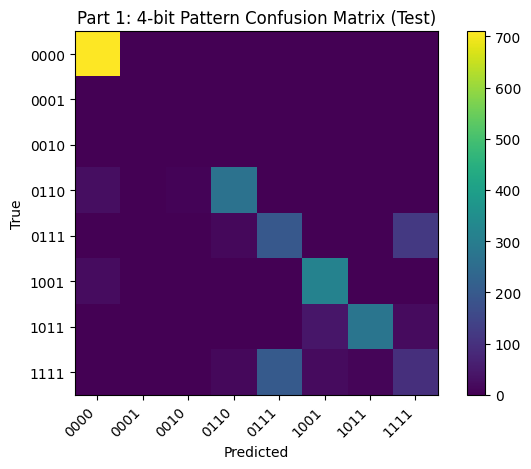

[[710   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [ 27   0   6 268   0   0   0   0]
 [  0   0   0  15 196   0   0 118]
 [ 23   2   0   0   0 314   0   0]
 [  1   1   0   0   0  43 275  20]
 [  0   0   0  14 200  20  10  96]]


In [13]:
# One confusion matrix over full 4-bit patterns (for TEST set)
true_str = [''.join(map(str, r.tolist())) for r in Y_test]
pred_str = [''.join(map(str, r.tolist())) for r in pred_bits_test]
labels = sorted(list(set(true_str) | set(pred_str)))
cm = confusion_matrix(true_str, pred_str, labels=labels)
plot_cm(cm, 'Part 1: 4-bit Pattern Confusion Matrix (Test)', labels)
print(cm)

## Part 2 — DNN Model 2 (Multi-label 4-bit classification)

You will build a DNN that predicts the 4 bits `[G, C, B, A]` as a **multi-label** output.
Each output dimension is an independent binary label.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 4 logits (apply sigmoid only for evaluation)
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**

Training:
- Use a **binary cross-entropy style loss on logits** (do not apply sigmoid inside the model).


In [14]:
# ----------------------------
# Part 2: Robust scaling (fit on train only)
# ----------------------------
scaler_2 = RobustScaler()
X_train_s2 = scaler_2.fit_transform(X_train).astype(np.float32)
X_test_s2  = scaler_2.transform(X_test).astype(np.float32)

Xtr2 = torch.from_numpy(X_train_s2)
Xte2 = torch.from_numpy(X_test_s2)
Ytr2 = torch.from_numpy(Y_train.astype(np.float32))
Yte2 = torch.from_numpy(Y_test.astype(np.float32))

train_loader_2 = DataLoader(TensorDataset(Xtr2, Ytr2), batch_size=BATCH_SIZE, shuffle=True)


In [15]:
## [ TODO 1 ]
# Define the DNN for Part 2.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 4
# - Hidden activations: ReLU
# - Output: 4 logits (no sigmoid inside the model)
# - Use BatchNorm and Dropout in hidden layers

class DNN_MultiLabel4(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, out_dim=OUT_DIM, p_drop=DROPOUT_P):
        super().__init__()
        # TODO: define layers
        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.do1 = nn.Dropout(p_drop)

        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.do2 = nn.Dropout(p_drop)

        self.out = nn.Linear(h2, out_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        # TODO: forward pass returning logits (N,4)
        x = self.do1(self.relu(self.bn1(self.fc1(x))))
        x = self.do2(self.relu(self.bn2(self.fc2(x))))
        return self.out(x)   # logits (no sigmoid)


In [ ]:
## [ TODO 2 ]
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: binary cross-entropy style loss on logits -- BCEWithLogitsLoss
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

model = DNN_MultiLabel4().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=L2_WEIGHT_DECAY)



In [ ]:
# ----------------------------
# Training loop scaffold
# ----------------------------
## [ TODO 3]
def train_part2(model, loader, epochs=EPOCHS):
    model.train()
    n = len(loader.dataset)
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs//2, epochs]:
            print(f"Part2 | Epoch {ep:4d} | avg loss = {total/n:.6f}")

@torch.no_grad()
def predict_bits_part2(model, X_np, threshold=0.5):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    probs = torch.sigmoid(logits).cpu().numpy()
    pred_bits = (probs >= threshold).astype(int)
    return pred_bits

# TODO: Train the model
train_part2(model, train_loader_2, epochs=EPOCHS)


Part2 | Epoch    1 | avg loss = 0.714683
Part2 | Epoch  500 | avg loss = 0.221392
Part2 | Epoch 1000 | avg loss = 0.214409


In [18]:
# ----------------------------
# Evaluation
# ----------------------------
pred_bits_train_ = predict_bits_part2(model, X_train_s2)
pred_bits_test_  = predict_bits_part2(model, X_test_s2)

bit_reports(Y_train, pred_bits_train_, split_name='Train', bit_names=label_cols)
bit_reports(Y_test,  pred_bits_test_,  split_name='Test',  bit_names=label_cols)


=== Bit-level Report | Train ===
              precision    recall  f1-score   support

           G     0.8267    0.8490    0.8377      2377
           C     0.9868    0.9280    0.9565      2263
           B     0.9975    0.9316    0.9635      3057
           A     1.0000    0.9720    0.9858      3144

   micro avg     0.9563    0.9245    0.9401     10841
   macro avg     0.9528    0.9201    0.9359     10841
weighted avg     0.9586    0.9245    0.9409     10841
 samples avg     0.6643    0.6520    0.6531     10841


Bit G | Train CM (rows=true 0/1, cols=pred 0/1):
[[2702  423]
 [ 359 2018]]

Bit C | Train CM (rows=true 0/1, cols=pred 0/1):
[[3211   28]
 [ 163 2100]]

Bit B | Train CM (rows=true 0/1, cols=pred 0/1):
[[2438    7]
 [ 209 2848]]

Bit A | Train CM (rows=true 0/1, cols=pred 0/1):
[[2358    0]
 [  88 3056]]

=== Bit-level Report | Test ===
              precision    recall  f1-score   support

           G     0.8306    0.8371    0.8338      1019
           C     0.9826    

c:\Users\luoyi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\luoyi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\luoyi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver

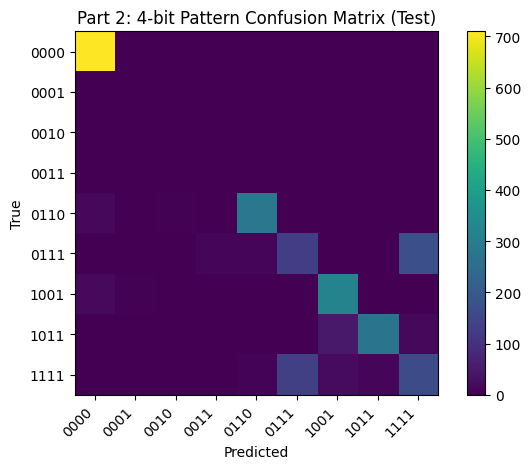

[[710   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [ 15   0   5   0 281   0   0   0   0]
 [  0   0   0  12  12 131   0   1 173]
 [ 17   4   0   0   0   0 318   0   0]
 [  1   1   0   0   0   0  48 274  16]
 [  0   0   0   0   8 135  21  11 165]]


In [19]:
# One confusion matrix over full 4-bit patterns (For TEST set)
true_str_ = [''.join(map(str, r.tolist())) for r in Y_test]
pred_str_ = [''.join(map(str, r.tolist())) for r in pred_bits_test_]
labels_ = sorted(list(set(true_str_) | set(pred_str_)))
cm_ = confusion_matrix(true_str_, pred_str_, labels=labels_)
plot_cm(cm_, 'Part 2: 4-bit Pattern Confusion Matrix (Test)', labels_)
print(cm_)

## Part 3 — DNN Model 3 (Multi-class fault type classification)

In this part, you will predict one of **6 fault types**.
The 4-bit label is converted to a single class in `{0,1,2,3,4,5}` using the provided mapping.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 6 logits
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**

Training:
- Use **cross-entropy loss** for multi-class classification.


In [20]:
# ----------------------------
# Part 3: Robust scaling (fit on train only)
# ----------------------------
scaler_3 = RobustScaler()
X_train_s3 = scaler_3.fit_transform(X_train).astype(np.float32)
X_test_s3  = scaler_3.transform(X_test).astype(np.float32)

ytr3 = torch.from_numpy(y_fault_train.astype(np.int64))
yte3 = torch.from_numpy(y_fault_test.astype(np.int64))
Xtr3 = torch.from_numpy(X_train_s3)
Xte3 = torch.from_numpy(X_test_s3)

train_loader_3 = DataLoader(TensorDataset(Xtr3, ytr3), batch_size=BATCH_SIZE, shuffle=True)


In [21]:
## [ TODO 1 ]
# Define the DNN for Part 3.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 6
# - Hidden activations: ReLU
# - Output: 6 logits
# - Use BatchNorm and Dropout in hidden layers

class DNN_MultiClass6(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, num_classes=6, p_drop=DROPOUT_P):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.do1 = nn.Dropout(p_drop)

        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.do2 = nn.Dropout(p_drop)

        self.out = nn.Linear(h2, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.do1(self.relu(self.bn1(self.fc1(x))))
        x = self.do2(self.relu(self.bn2(self.fc2(x))))
        return self.out(x)   # logits (N,6)


In [ ]:
## [ TODO 2 ]
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: CrossEntropyLoss
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

model = DNN_MultiClass6(num_classes=len(FAULT_NAMES)).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=L2_WEIGHT_DECAY)



In [ ]:
# ----------------------------
# Training loop scaffold
# ----------------------------
## [ TODO 3 ]
def train_part3(model, loader, epochs=EPOCHS):
    model.train()
    n = len(loader.dataset)
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs//2, epochs]:
            print(f"Part3 | Epoch {ep:4d} | avg loss = {total/n:.6f}")

@torch.no_grad()
def predict_part3(model, X_np):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    return torch.argmax(logits, dim=1).cpu().numpy()

# TODO: Train the model
train_part3(model, train_loader_3, epochs=EPOCHS)


Part3 | Epoch    1 | avg loss = 1.857339
Part3 | Epoch  500 | avg loss = 0.644013
Part3 | Epoch 1000 | avg loss = 0.646508



=== Part 3 | Train ===
              precision    recall  f1-score   support

    No Fault     0.9522    1.0000    0.9755      1655
          LG     0.8578    0.9544    0.9035       790
          LL     0.9233    0.9417    0.9324       703
         LLG     0.8128    0.8967    0.8527       794
         LLL     0.5050    0.8501    0.6336       767
        LLLG     1.0000    0.0013    0.0025       793

    accuracy                         0.8063      5502
   macro avg     0.8419    0.7740    0.7167      5502
weighted avg     0.8594    0.8063    0.7541      5502



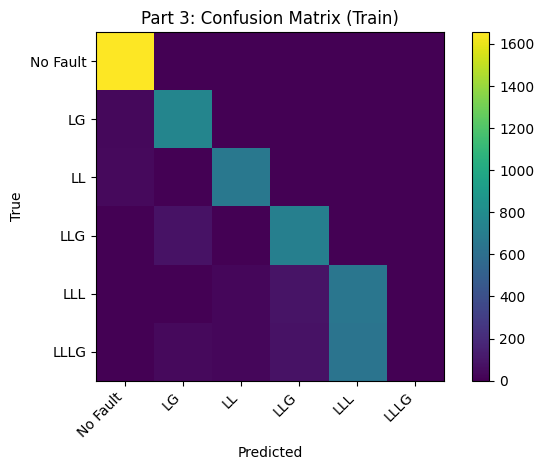


=== Part 3 | Test ===
              precision    recall  f1-score   support

    No Fault     0.9492    1.0000    0.9739       710
          LG     0.8560    0.9469    0.8992       339
          LL     0.9433    0.9402    0.9418       301
         LLG     0.8402    0.8971    0.8677       340
         LLL     0.4991    0.8693    0.6341       329
        LLLG     0.0000    0.0000    0.0000       340

    accuracy                         0.8075      2359
   macro avg     0.6813    0.7756    0.7195      2359
weighted avg     0.7198    0.8075    0.7560      2359



c:\Users\luoyi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\luoyi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\luoyi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

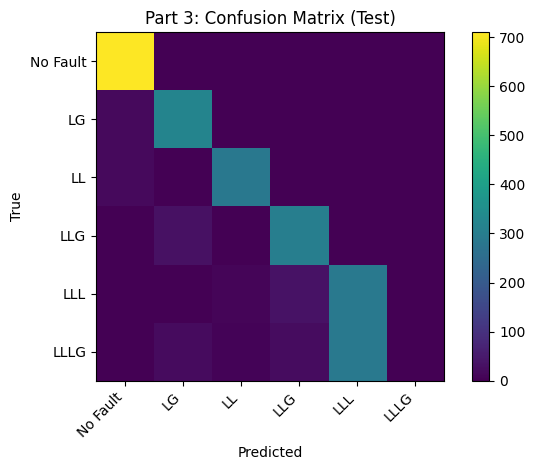

In [24]:
# ----------------------------
# Evaluation
# ----------------------------
pred_train = predict_part3(model, X_train_s3)
pred_test  = predict_part3(model, X_test_s3)

print('\n=== Part 3 | Train ===')
print(classification_report(y_fault_train, pred_train, target_names=FAULT_NAMES, digits=4))
cm_tr = confusion_matrix(y_fault_train, pred_train, labels=np.arange(len(FAULT_NAMES)))
plot_cm(cm_tr, 'Part 3: Confusion Matrix (Train)', FAULT_NAMES)

print('\n=== Part 3 | Test ===')
print(classification_report(y_fault_test, pred_test, target_names=FAULT_NAMES, digits=4))
cm_te = confusion_matrix(y_fault_test, pred_test, labels=np.arange(len(FAULT_NAMES)))
plot_cm(cm_te, 'Part 3: Confusion Matrix (Test)', FAULT_NAMES)


## Part 4 — Discussion

Answer **2–5 sentences** for each prompt.

1. Compare Parts 1–3. Which formulation fits this dataset best (regression-style, multi-label, or multi-class), and why?
2. When you used the bit-based approaches (Part 1 and Part 2), did you observe any **inconsistent 4-bit outputs** (invalid fault patterns)? What does that suggest?
3. Looking at confusion matrices, which fault types (or bit positions) were the hardest to predict? Give one plausible reason.

### Your answers
- Q1: The multi-label approach in Part 2 fits this dataset best. Each fault pattern is naturally composed of independent binary components, so modeling the task as multiple binary classifications aligns with the structure of the data. Compared to regression-style, it directly optimizes classification performance, and unlike multi-class softmax, it does not force mutual exclusivity between similar fault types. As a result, multi-label achieved better and more stable pattern-level performance.
- Q2: Yes, some inconsistent or less frequent 4-bit combinations were observed. Because each bit is predicted independently, the model can occasionally produce combinations that are rare or not strongly represented in the training data. This suggests that bit-wise independence may ignore structural dependencies between fault components. However, in Part 2, these inconsistencies were reduced due to the classification-oriented loss.
- Q3: The most difficult fault types were LLL and LLLG in Part 3, and the G bit in Parts 1 and 2. These classes share highly similar bit patterns, making them difficult to separate. In Part 3, softmax competition further amplified this issue, causing LLLG to be LLL. A plausible reason is that the underlying features do not provide strong separability between these closely related fault configurations.


## Part 5 — Open-ended extension: Binary classification (Fault vs No Fault)

In this part, you will create a **binary** classification problem:

- Class 0: **No Fault** (`[0,0,0,0]`)
- Class 1: **Fault** (any other pattern)

**Your task**: Using the best formulation you identified in Part 4, build a DNN to classify **Fault vs No Fault**.

Requirements:
- Use a **70% / 30%** train/test split (stratified)
- Use **RobustScaler** (fit on train only)
- Report **classification report** and **confusion matrix** on **train and test**

Implementation notes:
- First create a dataset with two classes by compressing all fault types into a single “Fault” class (and keeping “No Fault” as the other class).
- Keep your solution clean and focused: data, model, training, evaluation.


In [27]:
# 0 = No Fault (0000), 1 = Fault (anything else)
y_bin = (Y_bits.sum(axis=1) > 0).astype(int)

print("Binary counts:", dict(zip(["No Fault", "Fault"], np.bincount(y_bin))))
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X, y_bin,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_bin
)

print("Binary split sizes:", Xb_train.shape, Xb_test.shape)
scaler_bin = RobustScaler()
Xb_train_s = scaler_bin.fit_transform(Xb_train)
Xb_test_s  = scaler_bin.transform(Xb_test)
Xb_train_t = torch.tensor(Xb_train_s, dtype=torch.float32)
Xb_test_t  = torch.tensor(Xb_test_s, dtype=torch.float32)

yb_train_t = torch.tensor(yb_train, dtype=torch.float32).unsqueeze(1)  # (N,1)
yb_test_t  = torch.tensor(yb_test, dtype=torch.float32).unsqueeze(1)

train_loader_bin = DataLoader(TensorDataset(Xb_train_t, yb_train_t), batch_size=BATCH_SIZE, shuffle=True)
test_loader_bin  = DataLoader(TensorDataset(Xb_test_t,  yb_test_t),  batch_size=BATCH_SIZE, shuffle=False)




Binary counts: {'No Fault': np.int64(2365), 'Fault': np.int64(5496)}
Binary split sizes: (5502, 6) (2359, 6)


In [28]:
class DNN_Binary(nn.Module):
    def __init__(self, input_dim=6, h1=H1, h2=H2, p_drop=DROPOUT_P):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.do1 = nn.Dropout(p_drop)

        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.do2 = nn.Dropout(p_drop)

        self.out = nn.Linear(h2, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.do1(self.relu(self.bn1(self.fc1(x))))
        x = self.do2(self.relu(self.bn2(self.fc2(x))))
        return self.out(x)  # logits


In [29]:
model_bin = DNN_Binary(input_dim=X.shape[1]).to(device)
loss_fn_bin = nn.BCEWithLogitsLoss()
opt_bin = torch.optim.Adam(model_bin.parameters(), lr=LR, weight_decay=L2_WEIGHT_DECAY)


In [30]:
def train_binary(model, loader, epochs=EPOCHS):
    model.train()
    n = len(loader.dataset)
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt_bin.zero_grad()
            logits = model(xb)
            loss = loss_fn_bin(logits, yb)
            loss.backward()
            opt_bin.step()
            total += loss.item() * xb.size(0)
        if ep in [1, epochs//2, epochs]:
            print(f"Part5 | Epoch {ep:4d} | avg loss = {total/n:.6f}")

train_binary(model_bin, train_loader_bin, epochs=EPOCHS)


Part5 | Epoch    1 | avg loss = 0.644734
Part5 | Epoch  500 | avg loss = 0.062163
Part5 | Epoch 1000 | avg loss = 0.082866


In [ ]:
def eval_binary(model, X_np, y_true_np, split_name):
    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X_np, dtype=torch.float32).to(device)
        logits = model(X_t)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()
        y_pred = (probs >= 0.5).astype(int)

    print(f"\n=== Part 5 | {split_name} ===")
    print(classification_report(y_true_np, y_pred, target_names=["No Fault", "Fault"]))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true_np, y_pred))

eval_binary(model_bin, Xb_train_s, yb_train, "Train")
eval_binary(model_bin, Xb_test_s,  yb_test,  "Test")


=== Part 5 | Train ===
              precision    recall  f1-score   support

    No Fault       0.96      1.00      0.98      1655
       Fault       1.00      0.98      0.99      3847

    accuracy                           0.99      5502
   macro avg       0.98      0.99      0.98      5502
weighted avg       0.99      0.99      0.99      5502

Confusion Matrix:
[[1654    1]
 [  72 3775]]

=== Part 5 | Test ===
              precision    recall  f1-score   support

    No Fault       0.97      1.00      0.98       710
       Fault       1.00      0.99      0.99      1649

    accuracy                           0.99      2359
   macro avg       0.98      0.99      0.99      2359
weighted avg       0.99      0.99      0.99      2359

Confusion Matrix:
[[ 710    0]
 [  24 1625]]
